In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)
from peft import PeftModel
from nltk.translate.bleu_score import (
    sentence_bleu,
    SmoothingFunction
)
from rouge_score import rouge_scorer
from bert_score import score
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
dataset = load_dataset(
    "json",
    data_files="../dataset/finetune_dataset.json"
)["train"]

print("Total Dataset:", len(dataset))

Total Dataset: 32104


In [8]:
split_1 = dataset.train_test_split(
    test_size=0.2,
    seed=42
)

temp_dataset = split_1["test"]

split_2 = temp_dataset.train_test_split(
    test_size=0.5,
    seed=42
)

test_dataset = split_2["test"]

print("Test Dataset:", len(test_dataset))

Test Dataset: 3211


In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

model = PeftModel.from_pretrained(
    base_model,
    "../medical_lora_adapter"
)

model.eval()

print("LoRA model loaded!")

LoRA model loaded!


In [11]:
ground_truths = []
predictions = []

evaluation_size = 200

samples = test_dataset.select(
    range(
        min(
            evaluation_size,
            len(test_dataset)
        )
    )
)

for sample in samples:

    prompt = f"""### Instruction:
{sample['instruction']}

### Question:
{sample['input']}

### Response:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False
        )

    generated_text = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    prediction = generated_text.split(
        "### Response:"
    )[-1].strip()

    predictions.append(prediction)
    ground_truths.append(sample["output"])

print("Generated:", len(predictions))

Generated: 200


In [12]:
for i in range(5):

    print("="*100)

    print("QUESTION:")
    print(samples[i]["input"])

    print("\nGROUND TRUTH:")
    print(ground_truths[i])

    print("\nPREDICTION:")
    print(predictions[i])

QUESTION:
what does the term 'hyperglycemia' mean?

GROUND TRUTH:
hyperglycemia is the medical term for high blood sugar. it happens when your body has too little insulin or when it can't use insulin properly. our goal is to manage your care plan to prevent your blood sugar from getting too high for too long.

PREDICTION:
protecting your kidneys is a key part of your care. the best thing you can do is keep your blood sugar and blood pressure
QUESTION:
my friend with diabetes needs dialysis. am i going to end up like that?

GROUND TRUTH:
it is understandable to worry, but it is not inevitable. serious kidney damage is a risk, but you have a lot of power to prevent it. by actively managing your blood sugar and blood pressure, you give your kidneys the best possible protection for the future.

PREDICTION:
while severe kidney damage is a serious medical condition, it is not inevitable. by actively managing your blood sugar, blood pressure, and cholesterol, and by taking care of your overal

In [13]:
smooth = SmoothingFunction().method1

bleu_scores = []

for gt, pred in zip(
    ground_truths,
    predictions
):

    score_bleu = sentence_bleu(
        [gt.split()],
        pred.split(),
        smoothing_function=smooth
    )

    bleu_scores.append(score_bleu)

avg_bleu = np.mean(bleu_scores)

print("BLEU:", avg_bleu)

BLEU: 0.14631372118924818


In [14]:
scorer = rouge_scorer.RougeScorer(
    ["rouge1","rouge2","rougeL"],
    use_stemmer=True
)

rouge1 = []
rouge2 = []
rougeL = []

for gt, pred in zip(
    ground_truths,
    predictions
):

    scores = scorer.score(
        gt,
        pred
    )

    rouge1.append(scores["rouge1"].fmeasure)
    rouge2.append(scores["rouge2"].fmeasure)
    rougeL.append(scores["rougeL"].fmeasure)

avg_rouge1 = np.mean(rouge1)
avg_rouge2 = np.mean(rouge2)
avg_rougeL = np.mean(rougeL)

print("ROUGE-1:", avg_rouge1)
print("ROUGE-2:", avg_rouge2)
print("ROUGE-L:", avg_rougeL)

ROUGE-1: 0.43650337490524405
ROUGE-2: 0.25386469292284725
ROUGE-L: 0.34588174236687746


In [15]:
P, R, F1 = score(
    predictions,
    ground_truths,
    lang="en"
)

bert_precision = P.mean().item()
bert_recall = R.mean().item()
bert_f1 = F1.mean().item()

print("BERT Precision:", bert_precision)
print("BERT Recall:", bert_recall)
print("BERT F1:", bert_f1)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT Precision: 0.8766616582870483
BERT Recall: 0.8887016177177429
BERT F1: 0.8822580575942993


In [16]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

gt_embeddings = embedding_model.encode(
    ground_truths
)

pred_embeddings = embedding_model.encode(
    predictions
)

similarities = []

for gt_emb, pred_emb in zip(
    gt_embeddings,
    pred_embeddings
):

    sim = cosine_similarity(
        [gt_emb],
        [pred_emb]
    )[0][0]

    similarities.append(sim)

avg_similarity = np.mean(
    similarities
)

print(
    "Average Cosine Similarity:",
    avg_similarity
)

c:\Users\ROG\anaconda3\envs\RAG_model_chatbot_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ROG\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Average Cosine Similarity: 0.71939117


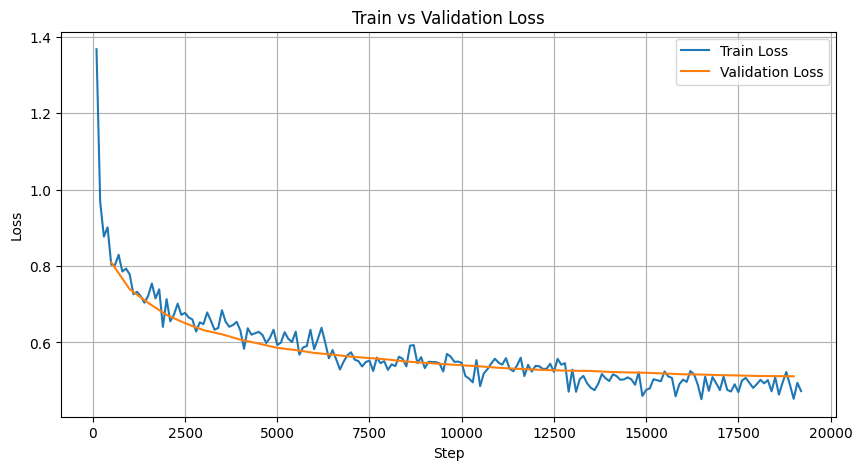

In [19]:
log_df = pd.read_csv(
    "../training_logs.csv"
)

train_logs = log_df[
    log_df["loss"].notna()
]

eval_logs = log_df[
    log_df["eval_loss"].notna()
]

plt.figure(figsize=(10,5))

plt.plot(
    train_logs["step"],
    train_logs["loss"],
    label="Train Loss"
)

plt.plot(
    eval_logs["step"],
    eval_logs["eval_loss"],
    label="Validation Loss"
)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

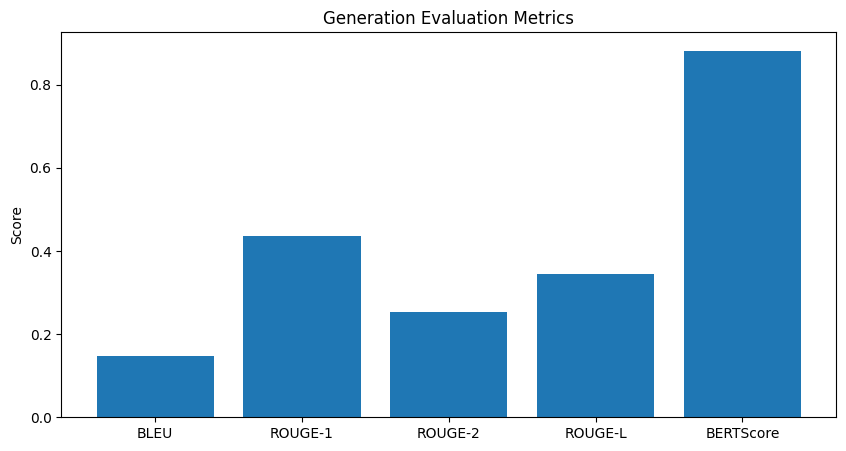

In [20]:
metrics = [
    "BLEU",
    "ROUGE-1",
    "ROUGE-2",
    "ROUGE-L",
    "BERTScore"
]

scores = [
    avg_bleu,
    avg_rouge1,
    avg_rouge2,
    avg_rougeL,
    bert_f1
]

plt.figure(figsize=(10,5))

plt.bar(
    metrics,
    scores
)

plt.title(
    "Generation Evaluation Metrics"
)

plt.ylabel(
    "Score"
)

plt.show()

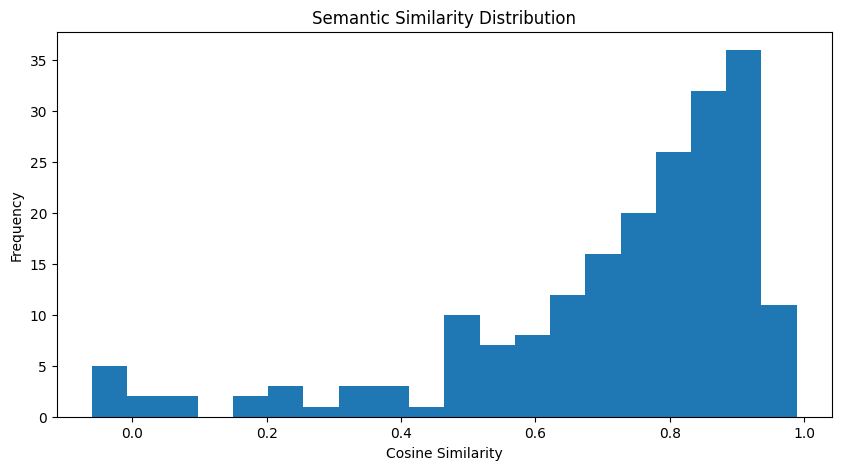

In [21]:
plt.figure(figsize=(10,5))

plt.hist(
    similarities,
    bins=20
)

plt.xlabel(
    "Cosine Similarity"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Semantic Similarity Distribution"
)

plt.show()

In [22]:
human_scores = {
    "Relevancy":4.6,
    "Accuracy":4.5,
    "Completeness":4.4,
    "Clarity":4.7
}

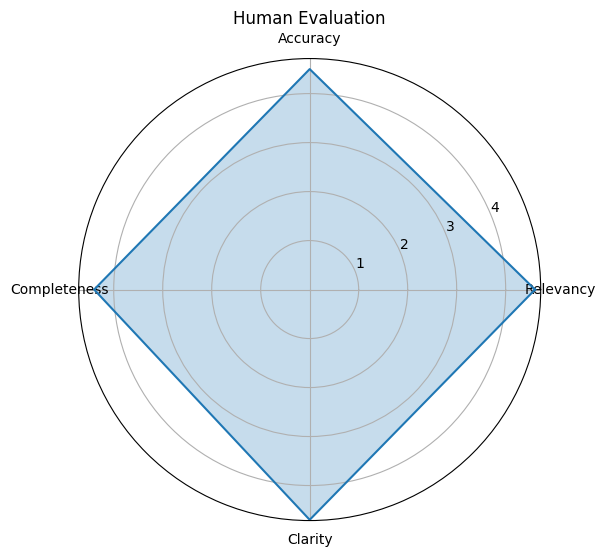

In [23]:
labels = list(human_scores.keys())

values = list(human_scores.values())

values += values[:1]

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

fig = plt.figure(figsize=(6,6))

ax = plt.subplot(
    111,
    polar=True
)

ax.plot(
    angles,
    values
)

ax.fill(
    angles,
    values,
    alpha=0.25
)

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    labels
)

plt.title(
    "Human Evaluation"
)

plt.show()